In [1]:
# Imports
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import fennel
from fennel import Fennel, TrackYieldResult, EMYieldResult, HadronYieldResult, ValidationError

print(f"Fennel version: {fennel.__version__}")

Fennel version: 2.0.0


In [2]:
# Configuration
PICS = '../pics/'
Path(PICS).mkdir(parents=True, exist_ok=True)

# Plotting settings
std_size = 8
lw = 2
fontsize = 12
h_length = 2
export_dpi = 300

In [3]:
# Create Fennel instance
fennel_instance = Fennel()

# Test parameters
test_energy = 1e7  # 10 TeV in MeV
wavelengths = np.linspace(300, 600, 100)  # nm
zgrid = np.linspace(0, 2500, 100)  # cm
angle_grid = np.linspace(0, 180, 100)  # degrees (not radians!)

## 1. Track Yields (Muons)

### v2.0 API: Result Containers

Instead of unpacking tuples, we get a structured result object with named attributes:

In [4]:
# New v2 API - returns TrackYieldResult
# Note: track_yields_v2 is for muon tracks (no particle parameter needed)
track_result = fennel_instance.track_yields_v2(
    energy=test_energy,
    function=True
)

# Beautiful string representation
print(track_result)
print()

# Access by name (no tuple unpacking!)
print(f"Energy: {track_result.energy} GeV")
print(f"Is function: {track_result.is_function}")
print(f"Interaction type: {track_result.interaction}")

TrackYieldResult(energy=10000000.0 GeV, interaction='total', mode=functional)

Energy: 10000000.0 GeV
Is function: True
Interaction type: total


In [5]:
# Evaluate the functions
# Note: dcounts(energy, wavelengths), angles(angle_grid, n, energy)
track_dcounts_val = track_result.dcounts(test_energy, wavelengths)
track_angles_val = track_result.angles(angle_grid, 1.33, test_energy)

print(f"Total photon count: {np.trapezoid(track_dcounts_val, wavelengths):.2e}")

Total photon count: 2.66e+03


### Even Simpler: Convenience Methods

For common use cases, use `quick_track()` with minimal parameters:

In [6]:
# Convenience method - even simpler!
# No grids needed, just energy
quick_result = fennel_instance.quick_track(
    energy=test_energy
)

# Same result structure
print(quick_result)

TrackYieldResult(energy=10000000.0 GeV, interaction='total', mode=array)


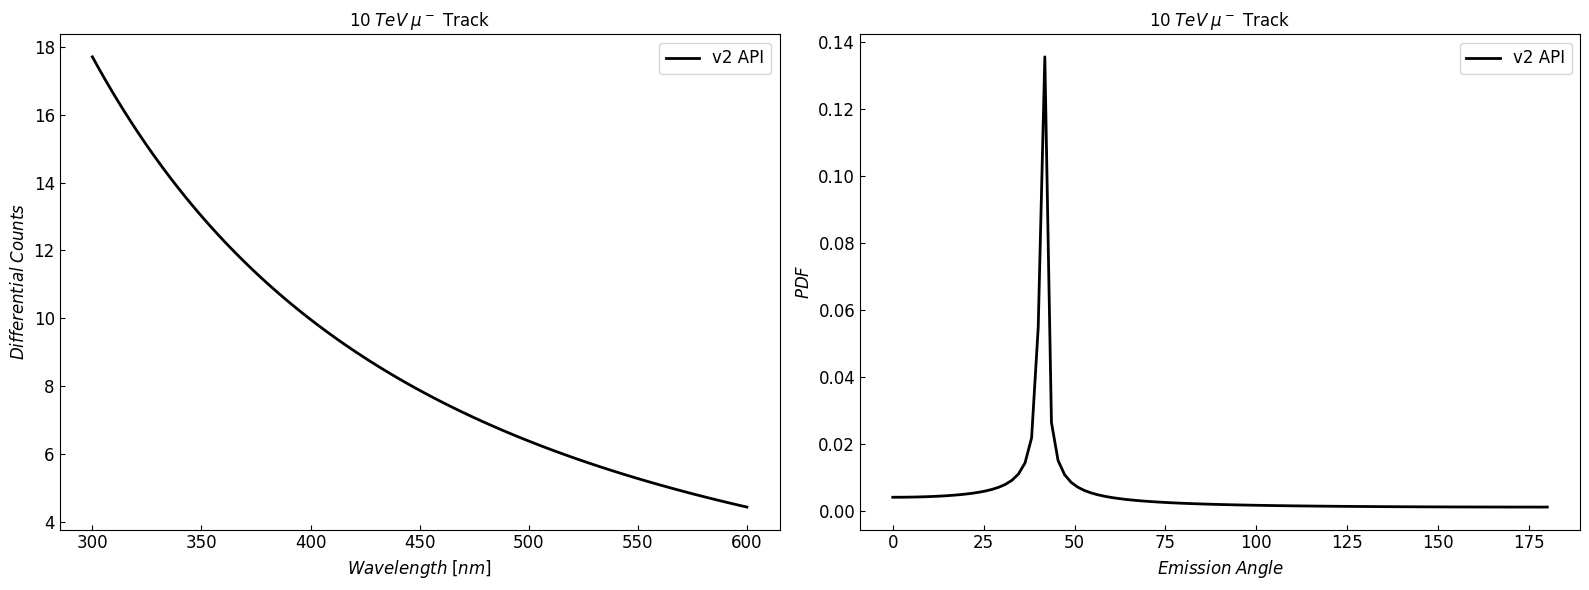

In [7]:
# Plotting
figure, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(std_size * 2, std_size * 6. / 8.),
)

# Wavelength distribution
ax1.plot(wavelengths, track_dcounts_val, linewidth=lw, color='k', label='v2 API')
ax1.set_xscale('linear')
ax1.set_yscale('linear')
ax1.set_xlabel(r'$Wavelength\;[nm]$', fontsize=fontsize)
ax1.set_ylabel(r'$Differential\;Counts$', fontsize=fontsize)
ax1.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax1.legend(fontsize=fontsize)
ax1.set_title(r"$10\;TeV\;\mu^-$ Track", fontsize=fontsize)

# Angular distribution
ax2.plot(angle_grid, track_angles_val / np.trapezoid(track_angles_val, x=angle_grid),
         linewidth=lw, color='k', label='v2 API')
ax2.set_xscale('linear')
ax2.set_yscale('linear')
ax2.set_xlabel(r'$Emission\;Angle$', fontsize=fontsize)
ax2.set_ylabel(r'$PDF$', fontsize=fontsize)
ax2.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax2.legend(fontsize=fontsize)
ax2.set_title(r"$10\;TeV\;\mu^-$ Track", fontsize=fontsize)

plt.tight_layout()
plt.show()

figure.savefig(PICS + "v2_Track_Example.png", bbox_inches='tight', dpi=export_dpi)

## 2. EM Cascade (Electrons)

### v2.0 API: EMYieldResult

EM cascades return additional information like longitudinal profiles:

In [8]:
# New v2 API - returns EMYieldResult
em_result = fennel_instance.em_yields_v2(
    energy=test_energy,
    particle=11,  # electron
    function=True
)

print(em_result)
print()
print(f"Particle: {em_result.particle_name}")
print(f"Has longitudinal profile: {em_result.longitudinal_profile is not None}")

EMYieldResult(energy=10000000.0 GeV, particle=electron, mode=functional)

Particle: electron
Has longitudinal profile: True


In [9]:
# Evaluate functions - clean named access!
# Note: dcounts(energy, wavelengths), longitudinal_profile(energy, zgrid), angles(angle_grid, n)
em_dcounts_val = em_result.dcounts(test_energy, wavelengths)
em_long_val = em_result.longitudinal_profile(test_energy, zgrid)
em_angles_val = em_result.angles(angle_grid, 1.33)

print(f"Total photon count: {np.trapezoid(em_dcounts_val, wavelengths):.2e}")

Total photon count: 9.30e+12


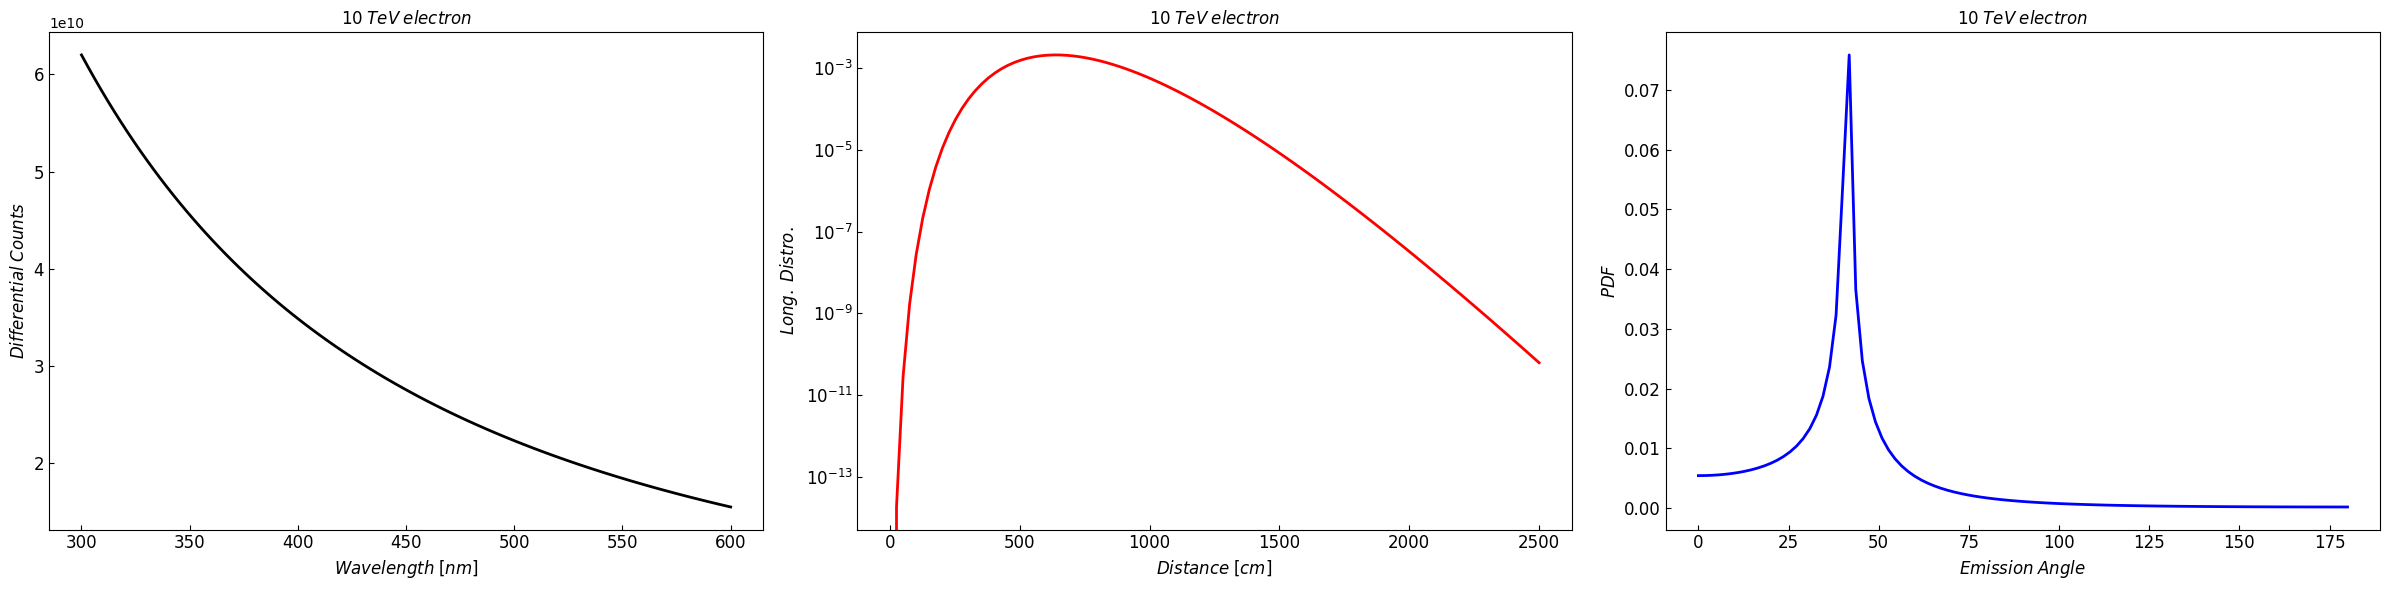

In [10]:
# Plotting
figure, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(std_size * 3, std_size * 6. / 8.),
)

# Wavelength
ax1.plot(wavelengths, em_dcounts_val, linewidth=lw, color='k')
ax1.set_xlabel(r'$Wavelength\;[nm]$', fontsize=fontsize)
ax1.set_ylabel(r'$Differential\;Counts$', fontsize=fontsize)
ax1.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax1.set_title(rf"$10\;TeV\;{em_result.particle_name}$", fontsize=fontsize)

# Longitudinal profile - flatten if needed
em_long_flat = em_long_val.flatten() if em_long_val.ndim > 1 else em_long_val
ax2.plot(zgrid, em_long_flat / np.trapezoid(em_long_flat, x=zgrid), linewidth=lw, color='r')
ax2.set_xlabel(r'$Distance\;[cm]$', fontsize=fontsize)
ax2.set_ylabel(r'$Long.\;Distro.$', fontsize=fontsize)
ax2.set_yscale('log')
ax2.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax2.set_title(rf"$10\;TeV\;{em_result.particle_name}$", fontsize=fontsize)

# Angular
ax3.plot(angle_grid, em_angles_val / np.trapezoid(em_angles_val, x=angle_grid),
         linewidth=lw, color='b')
ax3.set_xlabel(r'$Emission\;Angle$', fontsize=fontsize)
ax3.set_ylabel(r'$PDF$', fontsize=fontsize)
ax3.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax3.set_title(rf"$10\;TeV\;{em_result.particle_name}$", fontsize=fontsize)

plt.tight_layout()
plt.show()

figure.savefig(PICS + "v2_EM_Example.png", bbox_inches='tight', dpi=export_dpi)

## 3. Hadron Cascade (Pions)

### v2.0 API: HadronYieldResult

Hadron cascades include electromagnetic fraction information:

In [11]:
# New v2 API - returns HadronYieldResult
hadron_result = fennel_instance.hadron_yields_v2(
    energy=test_energy,
    particle=211,  # pi+
    function=True
)

print(hadron_result)
print()
print(f"Particle: {hadron_result.particle_name}")
print(f"Has EM fraction: {hadron_result.em_fraction is not None}")

HadronYieldResult(energy=10000000.0 GeV, particle=π+, em_frac=callable, mode=functional)

Particle: π+
Has EM fraction: True


In [12]:
# Evaluate - clean named attributes!
# Note: All callables have signatures: dcounts(energy, wavelengths), longitudinal_profile(energy, zgrid), angles(energy, angle_grid, n)
had_dcounts_val = hadron_result.dcounts(test_energy, wavelengths)
had_dcounts_sample_val = hadron_result.dcounts_sample(test_energy, wavelengths)
had_em_frac_mean = hadron_result.em_fraction(test_energy)
had_em_frac_samples = hadron_result.em_fraction_sample(test_energy)
had_long_val = hadron_result.longitudinal_profile(test_energy, zgrid)
had_angles_val = hadron_result.angles(test_energy, angle_grid, 1.33)

print(f"Total photon count: {np.trapezoid(had_dcounts_val, wavelengths):.2e}")
print(f"EM fraction (mean): {had_em_frac_mean:.3f}")
print(f"EM fraction (sample): {had_em_frac_samples:.3f}")

Total photon count: 1.05e+13
EM fraction (mean): 0.957
EM fraction (sample): 0.946


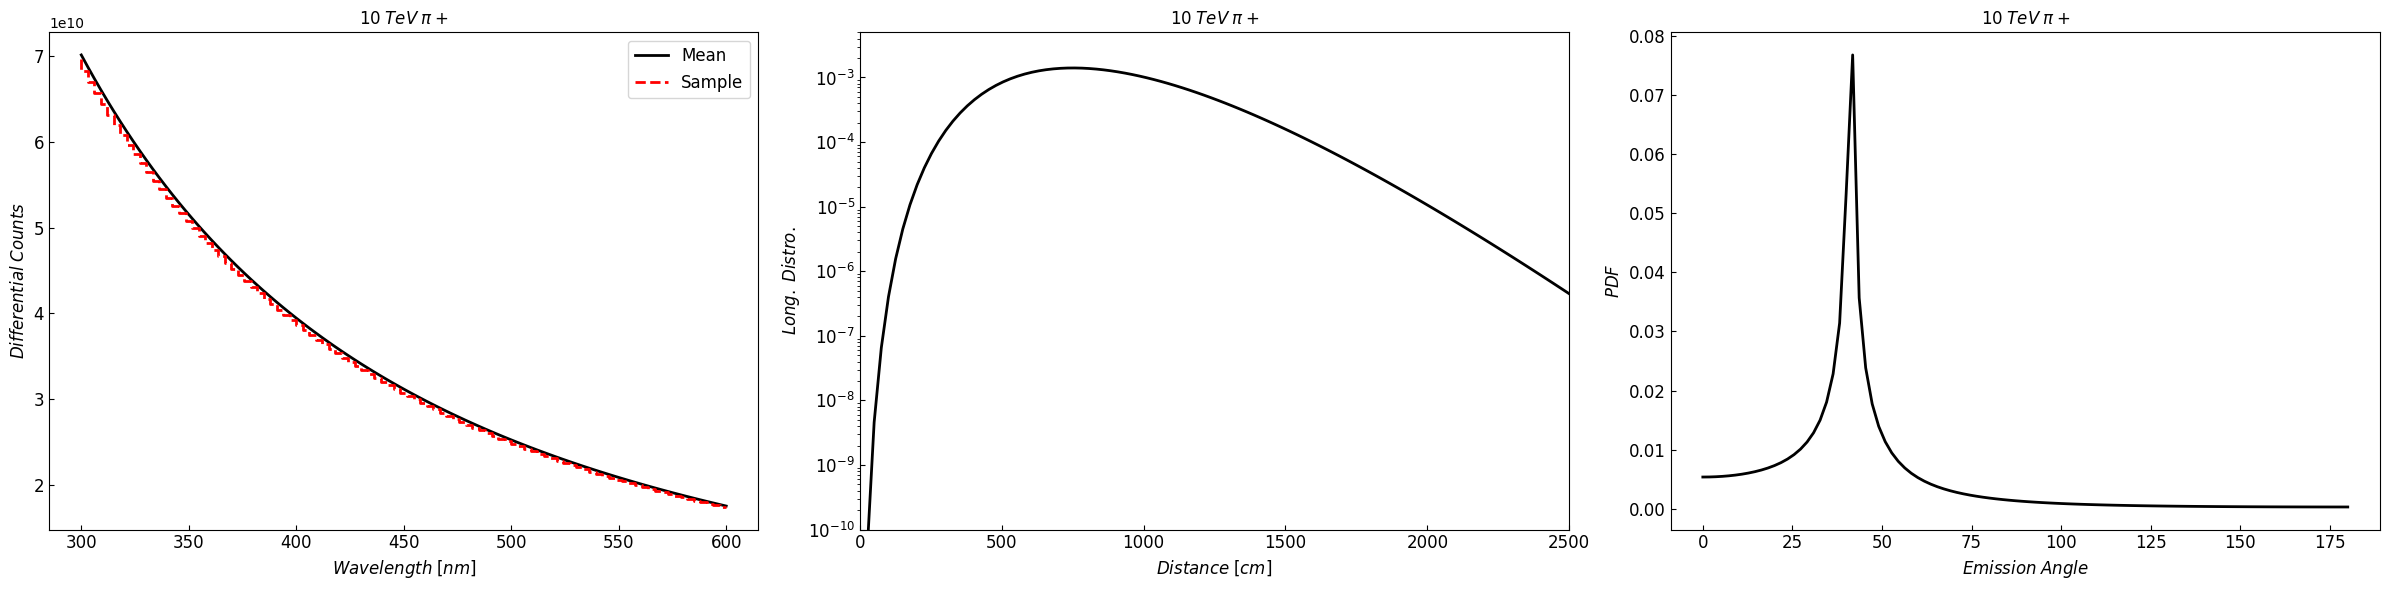

In [13]:
# Plotting
figure, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(std_size * 3, std_size * 6. / 8.),
)

# Wavelength (both mean and sample)
ax1.plot(wavelengths, had_dcounts_val, linewidth=lw, color='k', label='Mean')
ax1.step(wavelengths, had_dcounts_sample_val, linewidth=lw, color='r', ls='--', label='Sample')
ax1.set_xlabel(r'$Wavelength\;[nm]$', fontsize=fontsize)
ax1.set_ylabel(r'$Differential\;Counts$', fontsize=fontsize)
ax1.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax1.legend(fontsize=fontsize)
ax1.set_title(rf"$10\;TeV\;{hadron_result.particle_name}$", fontsize=fontsize)

# Longitudinal profile - flatten if needed
had_long_flat = had_long_val.flatten() if had_long_val.ndim > 1 else had_long_val
ax2.plot(zgrid, had_long_flat / np.trapezoid(had_long_flat, x=zgrid), linewidth=lw, color='k')
ax2.set_xlabel(r'$Distance\;[cm]$', fontsize=fontsize)
ax2.set_ylabel(r'$Long.\;Distro.$', fontsize=fontsize)
ax2.set_yscale('log')
ax2.set_xlim(0, 2500)
ax2.set_ylim(1e-10, 5e-3)
ax2.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax2.set_title(rf"$10\;TeV\;{hadron_result.particle_name}$", fontsize=fontsize)

# Angular
ax3.plot(angle_grid, had_angles_val / np.trapezoid(had_angles_val, x=angle_grid, axis=0),
         linewidth=lw, color='k')
ax3.set_xlabel(r'$Emission\;Angle$', fontsize=fontsize)
ax3.set_ylabel(r'$PDF$', fontsize=fontsize)
ax3.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax3.set_title(rf"$10\;TeV\;{hadron_result.particle_name}$", fontsize=fontsize)

plt.tight_layout()
plt.show()

figure.savefig(PICS + "v2_Hadron_Example.png", bbox_inches='tight', dpi=export_dpi)

## 4. Universal Convenience Method

### `calculate()`: Auto-detects particle type!

The most convenient way to get results - automatically routes to the correct method:

In [14]:
# Universal method - auto-detects particle type!
muon_result = fennel_instance.calculate(energy=test_energy, particle=13)
electron_result = fennel_instance.calculate(energy=test_energy, particle=11)
pion_result = fennel_instance.calculate(energy=test_energy, particle=211)

print("Automatically routed to correct methods:")
print(f"Muon (13) -> {type(muon_result).__name__}")
print(f"Electron (11) -> {type(electron_result).__name__}")
print(f"Pion (211) -> {type(pion_result).__name__}")

Automatically routed to correct methods:
Muon (13) -> TrackYieldResult
Electron (11) -> EMYieldResult
Pion (211) -> HadronYieldResult


In [15]:
# Compare photon yields across particle types

def eval_dcounts(result):
    return (result.dcounts(test_energy, wavelengths)
            if callable(result.dcounts) else result.dcounts)

muon_counts = eval_dcounts(muon_result)
electron_counts = eval_dcounts(electron_result)
pion_counts = eval_dcounts(pion_result)

print("Total photon counts at 10 TeV:")
print(f"  Muon: {np.trapezoid(muon_counts, wavelengths):.2e}")
print(f"  {electron_result.particle_name}: {np.trapezoid(electron_counts, wavelengths):.2e}")
print(f"  {pion_result.particle_name}: {np.trapezoid(pion_counts, wavelengths):.2e}")

Total photon counts at 10 TeV:
  Muon: 2.73e+03
  electron: 9.57e+12
  π+: 1.08e+13


<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_1887708/183738542.py:12: SyntaxWarning: invalid escape sequence '\;'
  ax.set_title("$10\;TeV$ Particle Comparison", fontsize=fontsize)


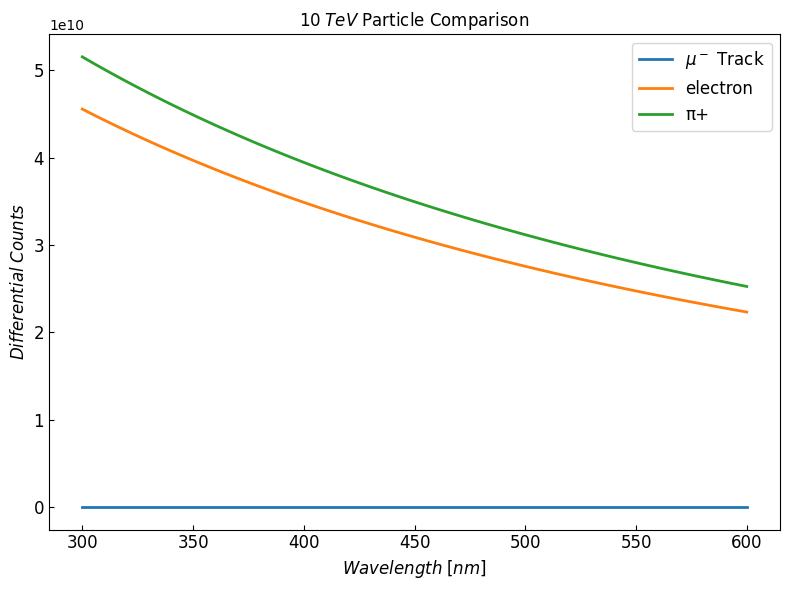

In [16]:
# Plotting comparison
figure, ax = plt.subplots(figsize=(std_size, std_size * 6. / 8.))

ax.plot(wavelengths, muon_counts, linewidth=lw, label=r'$\mu^-$ Track')
ax.plot(wavelengths, electron_counts, linewidth=lw, label=electron_result.particle_name)
ax.plot(wavelengths, pion_counts, linewidth=lw, label=pion_result.particle_name)

ax.set_xlabel(r'$Wavelength\;[nm]$', fontsize=fontsize)
ax.set_ylabel(r'$Differential\;Counts$', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize, direction='in')
ax.legend(fontsize=fontsize)
ax.set_title("$10\;TeV$ Particle Comparison", fontsize=fontsize)

plt.tight_layout()
plt.show()

figure.savefig(PICS + "v2_Particle_Comparison.png", bbox_inches='tight', dpi=export_dpi)

## 5. Input Validation

### Helpful Error Messages

The v2 API validates inputs and provides clear, actionable error messages:

In [17]:
# Example 1: Invalid energy
try:
    result = fennel_instance.track_yields_v2(
        energy=-1000  # Negative energy!
    )
except ValidationError as e:
    print("❌ ValidationError caught:")
    print(f"   {e}")
    print()

❌ ValidationError caught:
   Energy must be positive, got -1000 GeV. Example: energy=100.0



In [18]:
# Example 2: Invalid particle PDG
try:
    result = fennel_instance.em_yields_v2(
        energy=test_energy,
        particle=999  # Not in config!
    )
except ValidationError as e:
    print("❌ ValidationError caught:")
    print(f"   {e}")
    print()

❌ ValidationError caught:
   Unknown particle PDG ID: 999. Supported particles: [-2212, -211, -13, -11, 11, 13, 22, 130, 211, 2112, 2212].
Common examples:
  Tracks: 13 (muon)
  EM cascades: 11 (electron), -11 (positron), 22 (photon)
  Hadron cascades: 211 (π+), 2212 (proton), 2112 (neutron)



In [ ]:
# Example 3: Invalid wavelength range
try:
    invalid_wavelengths = np.linspace(-100, 200, 50)  # Negative wavelengths!
    # Use v2 method so wavelengths are validated at the API boundary
    fennel_instance.track_yields_v2(
        energy=test_energy,
        wavelengths=invalid_wavelengths
    )
except ValidationError as e:
    print("❌ ValidationError caught:")
    print(f"   {e}")
    print()

TypeError: 'numpy.ndarray' object is not callable

## 6. Backward Compatibility

### Old API Still Works!

All original methods are unchanged and produce identical results:

In [20]:
# Old API (v1.x style)
old_dcounts, old_angles = fennel_instance.track_yields(
    energy=test_energy,
    function=True
)

# New API (v2.0 style)
new_result = fennel_instance.track_yields_v2(
    energy=test_energy,
    function=True
)

# Verify they're the same functions
old_counts_val = old_dcounts(test_energy, wavelengths)
new_counts_val = new_result.dcounts(test_energy, wavelengths)

print("Backward compatibility check:")
print(f"  Max difference: {np.max(np.abs(old_counts_val - new_counts_val)):.2e}")
print(f"  Results identical: {np.allclose(old_counts_val, new_counts_val)}")
print()
print("✅ Old code continues to work perfectly!")

Backward compatibility check:
  Max difference: 0.00e+00
  Results identical: True

✅ Old code continues to work perfectly!


## Summary

### v2.0 API Benefits:

1. **Clearer Code**: Named attributes instead of tuple unpacking
2. **Better Errors**: Validation with helpful messages
3. **Less Typing**: Convenience methods for common cases
4. **Auto-routing**: `calculate()` detects particle type
5. **Self-documenting**: Pretty print shows what you have
6. **100% Compatible**: All old code still works

### Migration Recommendations:

- **New code**: Use `*_v2()` methods or `calculate()`
- **Existing code**: No changes needed, or migrate gradually
- **Quick prototyping**: Use `quick_track()` or `quick_cascade()`
- **Production**: Use `*_v2()` methods for explicit control

See `UPGRADE_GUIDE_V2.md` for complete details!

In [ ]:
# Reload fennel.results to pick up recent edits
import importlib
import fennel.results as fr
importlib.reload(fr)
print('Reloaded fennel.results')

Reloaded fennel.results


In [ ]:
# Reload fennel.fennel to refresh class imports, then recreate instance
import importlib
import fennel.fennel as ff
importlib.reload(ff)
from fennel.fennel import Fennel
fennel_instance = Fennel()
print('Reloaded fennel.fennel and recreated Fennel instance')

Reloaded fennel.fennel and recreated Fennel instance
